In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

In [39]:
# Hubble Constant (from Planck18)
H_0 = cosmo.H0

# Speed of Light
c_si = c.to(u.m / u.s)
c_kms = c.to(u.km / u.s)

# Gravitational Constant
G_si = G.to(u.m**3 / (u.kg * u.s**2))
G_pc = G.to(u.pc**3 / (u.Msun * u.s**2))


In [40]:
df = pd.read_csv("/content/Skyserver_SQL6_29_2025 7_24_17 AM.csv", sep=',', comment='#')


In [41]:
print(df.columns)

Index(['objid', 'ra', 'dec', 'photoz', 'photozerr', 'specz', 'speczerr',
       'proj_sep', 'umag', 'umagerr', 'gmag', 'gmagerr', 'rmag', 'rmagerr',
       'obj_type'],
      dtype='object')


In [42]:
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',        # Take the mean of all spec-z values for that object
    'ra': 'first',          # Use the first RA value (assumed constant for the object)
    'dec': 'first',         # Use the first Dec value (same reason as above)
    'proj_sep': 'first'     # Use the first projected separation value
}).reset_index()

In [43]:
# Calculating the average specz for each id:
averaged_df = df.groupby('objid').agg({'specz': 'mean','ra': 'first','dec': 'first','proj_sep': 'first',}).reset_index()
averaged_df.describe()['specz']

,specz
count,92.000000
mean,0.080838
std,0.008578
min,0.069976
25%,0.077224
50%,0.080961
75%,0.082797
max,0.150886


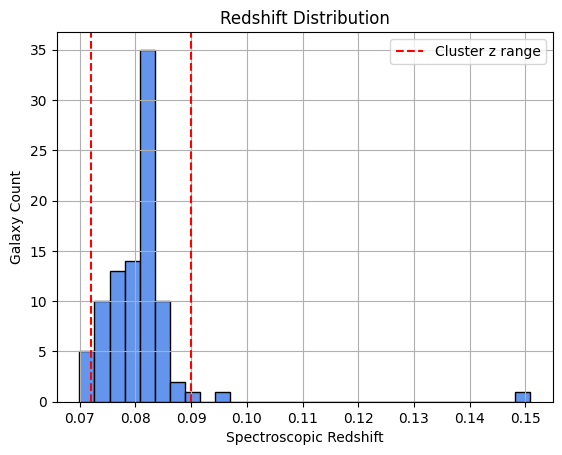

In [44]:
z_min = 0.072
z_max = 0.090
cluster_members = averaged_df[(averaged_df['specz'] >= z_min) & (averaged_df['specz'] <= z_max)]
import matplotlib.pyplot as plt

plt.hist(averaged_df['specz'], bins=30, color='cornflowerblue', edgecolor='black')
plt.axvline(z_min, color='red', linestyle='--', label='Cluster z range')
plt.axvline(z_max, color='red', linestyle='--')
plt.xlabel('Spectroscopic Redshift')
plt.ylabel('Galaxy Count')
plt.title('Redshift Distribution')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# Filtering the data based on specz values, used 3 sigma deviation from mean as upper limit.
# Calculate mean and standard deviation
z_mean = averaged_df['specz'].mean()
z_std = averaged_df['specz'].std()

# Calculate 3-sigma bounds
z_lower = z_mean - 3 * z_std
z_upper = z_mean + 3 * z_std

print(f"Mean z: {z_mean:.5f}")
print(f"Standard Deviation: {z_std:.5f}")
print(f"3σ Range: {z_lower:.5f} to {z_upper:.5f}")


Mean z: 0.08084
Standard Deviation: 0.00858
3σ Range: 0.05510 to 0.10657


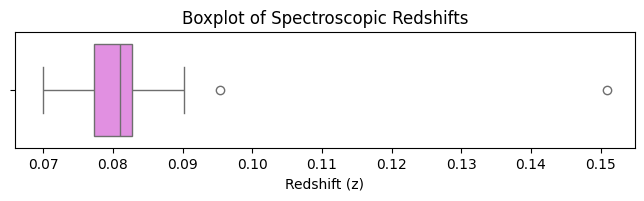

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 1.5))
sns.boxplot(x=averaged_df['specz'], color='violet')
plt.title("Boxplot of Spectroscopic Redshifts")
plt.xlabel("Redshift (z)")
plt.show()


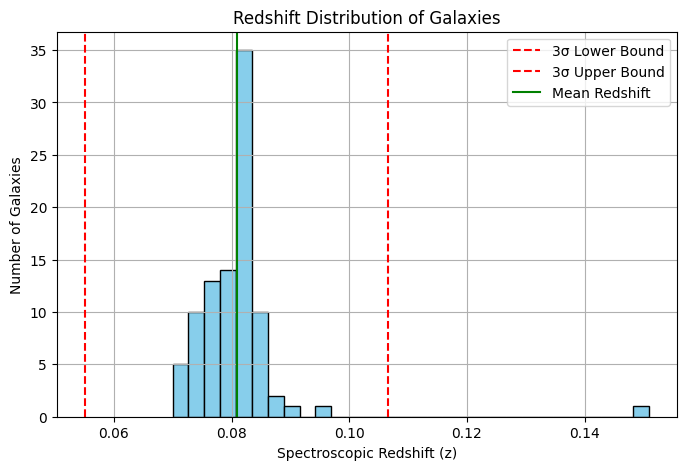

In [47]:
plt.figure(figsize=(8, 5))
plt.hist(averaged_df['specz'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(z_lower, color='red', linestyle='--', label='3σ Lower Bound')
plt.axvline(z_upper, color='red', linestyle='--', label='3σ Upper Bound')
plt.axvline(z_mean, color='green', linestyle='-', label='Mean Redshift')
plt.xlabel("Spectroscopic Redshift (z)")
plt.ylabel("Number of Galaxies")
plt.title("Redshift Distribution of Galaxies")
plt.legend()
plt.grid(True)
plt.show()


In [48]:
cluster_members = averaged_df[
    (averaged_df['specz'] >= z_lower) &
    (averaged_df['specz'] <= z_upper)
].copy()

print(f"Selected {len(cluster_members)} cluster members after 3σ filtering.")


Selected 91 cluster members after 3σ filtering.


In [49]:
from astropy.constants import c
import astropy.units as u

# Convert c to km/s
c_kms = c.to(u.km / u.s).value

# Add a velocity column (v = z * c)
cluster_members['velocity'] = cluster_members['specz'] * c_kms

# Check it out
cluster_members[['specz', 'velocity']].head()


,specz,velocity
0,0.082457,24719.932747
1,0.081218,24348.666769
2,0.079564,23852.805546
3,0.080842,24235.764929
4,0.084575,25355.070050


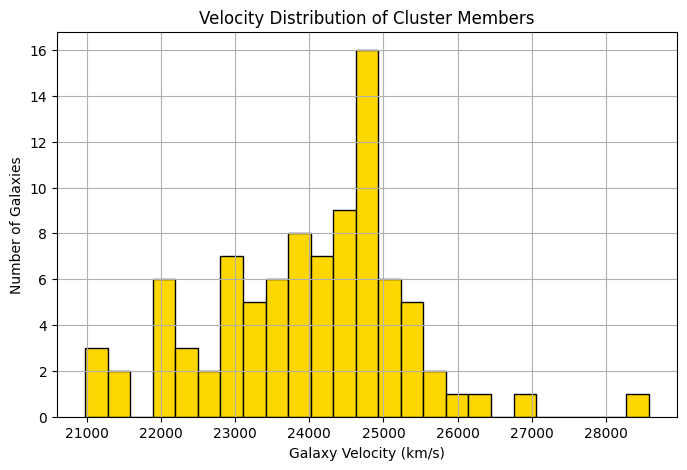

In [50]:
#plot the velocity column created as hist
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(cluster_members['velocity'], bins=25, color='gold', edgecolor='black')
plt.xlabel("Galaxy Velocity (km/s)")
plt.ylabel("Number of Galaxies")
plt.title("Velocity Distribution of Cluster Members")
plt.grid(True)
plt.show()


In [51]:
# Velocity dispersion in km/s
sigma_v = cluster_members['velocity'].std()

print(f"Velocity Dispersion (σᵥ): {sigma_v:.2f} km/s")


Velocity Dispersion (σᵥ): 1316.15 km/s


In [52]:
from astropy.constants import c
import astropy.units as u
import numpy as np

# Get mean redshift of the cluster
z_cluster = cluster_members['specz'].mean()

# Convert c to km/s
c_kms = c.to(u.km / u.s).value

# Apply the relativistic Doppler formula
z = cluster_members['specz']
v_rel = c_kms * ((1 + z)**2 - (1 + z_cluster)**2) / ((1 + z)**2 + (1 + z_cluster)**2)

# Add velocity column to the DataFrame
cluster_members['rel_velocity'] = v_rel

# Calculate the velocity dispersion (standard deviation of the relative velocities)
sigma_rel = np.std(v_rel)

print(f"Relativistic Velocity Dispersion (σᵥ): {sigma_rel:.2f} km/s")


Relativistic Velocity Dispersion (σᵥ): 1211.78 km/s


In [53]:
cluster_members['rel_velocity'].describe()

,rel_velocity
count,91.000000
mean,-2.449331
std,1218.492945
min,-2814.230840
25%,-806.606785
50%,237.179091
75%,754.977576
max,4206.136789


In [54]:
cluster_redshift = cluster_members['specz'].mean()
disp = cluster_members['rel_velocity'].std()
disp = sigma_rel
print(f"The value of the cluster redshift = {cluster_redshift:.4f}")
print(f"The characteristic value of velocity dispersion of the cluster along the line of sight = {disp:.4f} km/s.")

The value of the cluster redshift = 0.0801
The characteristic value of velocity dispersion of the cluster along the line of sight = 1211.7794 km/s.


### Step 4: Visualizing Angular Separation of Galaxies
We plot a histogram of the projected (angular) separation of galaxies from the cluster center. This helps us understand the spatial distribution of galaxies within the cluster field.

- The x-axis represents the angular separation (in arcminutes or degrees, depending on units).
- The y-axis shows the number of galaxies at each separation bin.



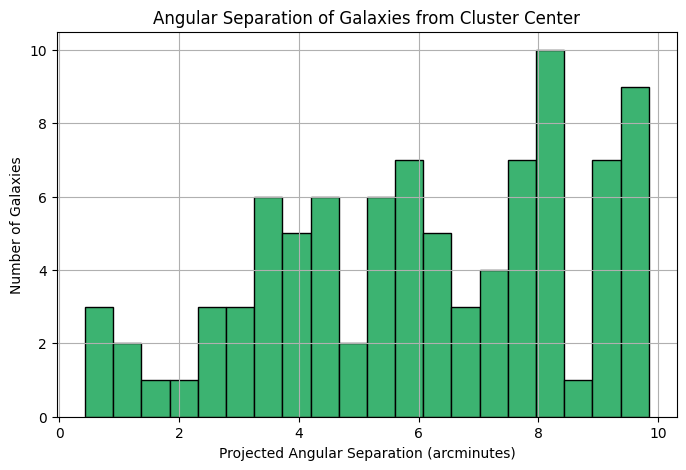

In [55]:
#Plot histogram for proj sep column
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(cluster_members['proj_sep'], bins=20, color='mediumseagreen', edgecolor='black')
plt.xlabel("Projected Angular Separation (arcminutes)")
plt.ylabel("Number of Galaxies")
plt.title("Angular Separation of Galaxies from Cluster Center")
plt.grid(True)
plt.show()


In [56]:
import numpy as np
from astropy.constants import c
import astropy.units as u

# Inputs
z = cluster_members['specz'].mean()
q0 = -0.534
H0 = 67.66 * u.km / u.s / u.Mpc
theta_arcmin = cluster_members['proj_sep'].mean()  # use .max() if you prefer largest extent

# Step 1: Co-moving distance (r)
cz = (c.to(u.km/u.s) * z).value  # km/s
r = (cz / H0.value) * (1 - (z**2) / (2 * (1 + q0)))  # in Mpc

# Step 2: Angular diameter distance (ra = DA)
ra = r / (1 + z)  # in Mpc

# Step 3: Angular size θ in radians
theta_rad = np.deg2rad(theta_arcmin / 60)

# Step 4: Physical diameter
diameter = ra * theta_rad  # in Mpc

# Display results
print(f"r = {r:.3f} Mpc")
print(f"ra = {ra:.3f} Mpc")
print(f"diameter = {diameter:.3f} Mpc")


r = 352.330 Mpc
ra = 326.211 Mpc
diameter = 0.577 Mpc


In [57]:
from astropy.constants import G
import astropy.units as u

# Inputs
disp_mps = disp * 1000  # convert km/s to m/s
radius_m = (diameter / 2) * 1e6 * 3.086e16  # half diameter in meters (1 Mpc = 3.086e22 m)
G_si = G.value  # Gravitational constant in m^3 / (kg s^2)

# Dynamical mass calculation in kg
M_dyn_kg = 3 * (disp_mps**2) * radius_m / G_si

# Convert to solar masses (1 solar mass ≈ 2e30 kg)
M_dyn_solar = M_dyn_kg / (2e30)

print(f"Dynamical Mass of the cluster is {M_dyn_solar:.2e} solar mass")


Dynamical Mass of the cluster is 2.94e+14 solar mass
